# Effect of gaussian filter on vorticity

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from altimetry_filter import define_eta, add_grid_metrics
from swot import browse_swot_2km
from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
    drifters_structure,
)
from diagnosis import (
    generate_0_15m_coloc_dataframe,
    sel_structure,
    compute_variance_groupby,
    compute_variance,
    prepared_alti,
    put_fig_letter,
)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, structure

depthcolor = {0: "navy", 15: "green", 50: "yellowgreen", 100: "yellow"}


dfs = browse_swot_2km().reset_index()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [2]:
cutoff = list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3))
cutoff

[4000.0,
 6000.0,
 8000.0,
 10000.0,
 12000.0,
 14000.0,
 16000.0,
 18000.0,
 20000.0,
 25000.0,
 30000.0,
 35000.0,
 40000.0,
 45000.0,
 50000.0,
 55000.0]

In [49]:
len(cutoff)

16

In [5]:
pass_ = 3
product = "swot2km"
cycle = 513
mean_sla = False
cutoff_ = cutoff[4]


def vorticity_dataset(cutoff_):
    # General
    from cstes import zarr_dir

    ds = xr.open_dataset(
        os.path.join(
            zarr_dir,
            "before_coloc",
            "preprocessed_swot",
            product,
            "general",
            f"pass{pass_}_{product}_general.nc",
        )
    )

    method = "gaussian_aviso"
    # Gaussian
    from cstes import zarr_dir

    dsg = xr.open_dataset(
        os.path.join(
            zarr_dir,
            "before_coloc",
            "preprocessed_swot",
            product,
            method,
            f"pass{pass_}_{product}_{method}_{int(cutoff_)}.nc",
        )
    )
    print(cutoff_)

    dsg_ = dsg.stack(z=("num_lines", "num_pixels"))
    ds_ = ds.stack(z=("num_lines", "num_pixels"))

    df_ = (
        ds_.to_dataframe()
        .iloc[:, :-2]
        .reset_index()
        .set_index(["cycle_number", "longitude", "latitude"])
    )
    dfg_ = (
        dsg_.to_dataframe()
        .iloc[:, :-2]
        .reset_index()
        .set_index(["cycle_number", "longitude", "latitude"])
    )

    df_ = df_.loc[dfg_.index]
    df = pd.concat([df_, dfg_], axis=1)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    ds = (
        df.reset_index()
        .set_index(["cycle_number", "num_lines", "num_pixels"])
        .to_xarray()
    )

    ds["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(ds.latitude * np.pi / 180)
    g = 9.81
    v = "etaf"
    from swot import rotate

    ds["ggde_" + v] = g * rotate(ds["dx_" + v], ds["dy_" + v], ds["phi"])[0]
    ds["ggdn_" + v] = g * rotate(ds["dx_" + v], ds["dy_" + v], ds["phi"])[1]
    ds["vorticity_" + v] = g * (ds["dxx_" + v] + ds["dyy_" + v]) / ds.f**2
    ds["strain_s_" + v] = g * (ds["dxx_" + v] - ds["dyy_" + v]) / ds.f**2
    ds["strain_n_" + v] = -2 * g * (ds["dxy_" + v] - ds["dxy_" + v]) / ds.f**2
    return ds

4000.0
6000.0
8000.0
10000.0
12000.0
14000.0
16000.0
18000.0
20000.0
25000.0
30000.0
35000.0
40000.0
45000.0
50000.0
55000.0


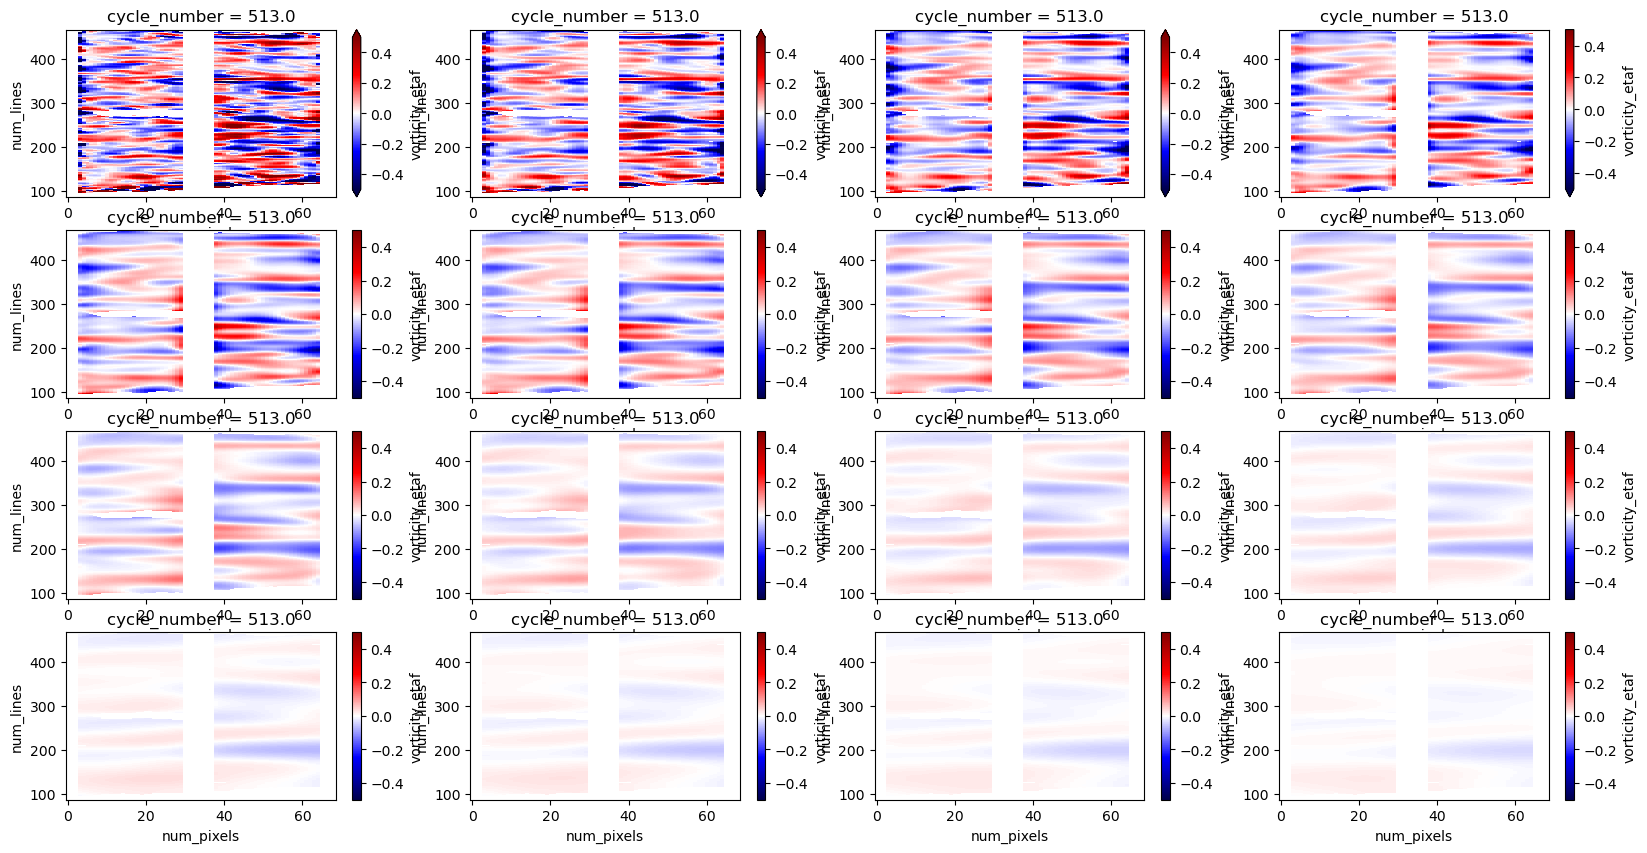

In [13]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.flatten()
i = 0
for cutoff_ in cutoff:
    ds1 = vorticity_dataset(cutoff_)
    ax = axs[i]
    i += 1
    ds1.sel(cycle_number=cycle).vorticity_etaf.plot(
        ax=ax, vmin=-0.5, vmax=0.5, cmap="seismic"
    )

In [7]:
ds = vorticity_dataset(cutoff_)

12000.0


In [12]:
ds.sel(
    cycle_number=cycle
).vorticity_etaf  # .plot(ax=ax), vmin=-0.5, vmax=0.5, cmap='seismic')

<xarray.DataArray 'vorticity_etaf' (num_lines: 381, num_pixels: 69)> Size: 210kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    cycle_number  float64 8B 513.0
  * num_lines     (num_lines) int64 3kB 87 88 89 90 91 ... 463 464 465 466 467
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68